# BootFlow: Bootstrapped Flow Matching Policy for Online RL (K=5)

Combines:
1. **Flow Matching** (instead of diffusion) for the policy - simpler and faster
2. **Bootstrapped exploration** via K heads with Thompson sampling
   (inspired by "Deep Exploration via Bootstrapped DQN", Osband et al. 2016)
3. **Soft Actor-Critic** style training with twin Q-networks

Architecture:
```
State s ──→ [Shared Backbone: 3 MLP layers, 256 units] ──→ features
                                  │
            ┌────────┬────────┬───┴────┬────────┬────────┐
            ▼        ▼        ▼        ▼        ▼
          Head₁    Head₂    Head₃    Head₄    Head₅
         (1 layer)(1 layer)(1 layer)(1 layer)(1 layer)
            │        │        │        │        │
          Flow₁    Flow₂    Flow₃    Flow₄    Flow₅
```

**Features:**
- K=5 heads for bootstrapped exploration
- Head disagreement metric (epistemic uncertainty)
- Multiple evaluation modes: single head, ensemble mean, Thompson sampling

In [1]:
!pip install metaworld gymnasium torch numpy matplotlib wandb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 45.5 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 110.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 29.2 MB/s eta 0:00:00


In [12]:
# Load in notebook
from dotenv import load_dotenv
import os

load_dotenv()
wandb_api_key = os.getenv('WANDB_API_KEY')

! wandb login "{wandb_api_key}"

wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


In [13]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import random
import metaworld
import time
import math
import wandb
from typing import Optional, Dict, Tuple, List

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Hyperparameters

**K=5 heads** for bootstrapped exploration with Thompson sampling

In [16]:
class Config:
    # Environment
    task_name = "push-v3"
    max_episode_steps = 500
    seed = 100

    # Training
    total_steps = 500_000
    start_training = 5000
    batch_size = 1024
    replay_buffer_size = 1_000_000
    updates_per_step = 1

    # Networks
    hidden_dim = 256
    backbone_layers = 3           # shared backbone depth
    head_layers = 1               # per-head depth
    lr_actor = 3e-4
    lr_critic = 3e-4

    # RL
    gamma = 0.99
    tau = 0.005
    grad_clip = 1.0

    # Flow Matching
    T = 10                        # integration steps for sampling
    T_disagree = 5                # fewer steps for disagreement (speed)
    sigma_min = 1e-4              # minimum noise for stability

    # Entropy
    alpha = 1.0                   # fixed entropy temperature (lambda)
    weight_clamp = 20.0           # clamp importance weights

    # Bootstrapping
    num_heads = 5                 # K=5 for bootstrapped exploration
    bootstrap_prob = 0.8          # prob of including sample per head

    # Logging
    eval_interval = 10_000
    eval_episodes = 10
    log_interval = 5000
    disagreement_samples = 256    # batch size for disagreement computation

cfg = Config()
print(f"Task: {cfg.task_name}")
print(f"Number of heads (K): {cfg.num_heads}")
print(f"Bootstrap prob: {cfg.bootstrap_prob}")
print(f"Flow steps (T): {cfg.T}, Disagreement steps: {cfg.T_disagree}")

Task: push-v3
Number of heads (K): 5
Bootstrap prob: 0.8
Flow steps (T): 10, Disagreement steps: 5


## 2. MetaWorld ML1 Environment

In [17]:
def make_metaworld_envs(task_name, seed=0):
    """Create separate MetaWorld ML1 train and test environments."""
    ml1 = metaworld.ML1(task_name, seed=seed)
    train_env_cls = ml1.train_classes[task_name]
    train_env = train_env_cls()
    train_env.set_task(ml1.train_tasks[0])

    ml1_test = metaworld.ML1(task_name, seed=seed+1000)
    test_env_cls = ml1_test.train_classes[task_name]
    test_env = test_env_cls()
    test_env.set_task(ml1_test.train_tasks[0])

    return train_env, test_env

train_env, test_env = make_metaworld_envs(cfg.task_name, seed=cfg.seed)
obs, _ = train_env.reset()
obs_dim = obs.shape[0]
act_dim = train_env.action_space.shape[0]
act_limit = float(train_env.action_space.high[0])

print(f"Task: {cfg.task_name}")
print(f"Obs dim: {obs_dim}, Act dim: {act_dim}, Act limit: {act_limit}")

Task: push-v3
Obs dim: 39, Act dim: 4, Act limit: 1.0


## 3. Replay Buffer with Bootstrap Masks

Each transition is randomly assigned to a subset of heads (Bernoulli mask).
This creates different "bootstrapped" datasets for each head.

In [18]:
class BootstrapReplayBuffer:
    """Replay buffer that stores bootstrap masks for each transition."""

    def __init__(self, capacity: int, obs_dim: int, act_dim: int, 
                 num_heads: int, bootstrap_prob: float = 0.8):
        self.capacity = capacity
        self.num_heads = num_heads
        self.bootstrap_prob = bootstrap_prob
        self.ptr = 0
        self.size = 0

        self.obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, act_dim), dtype=np.float32)
        self.rewards = np.zeros(capacity, dtype=np.float32)
        self.next_obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.dones = np.zeros(capacity, dtype=np.float32)
        self.masks = np.zeros((capacity, num_heads), dtype=np.float32)

    def add(self, obs, action, reward, next_obs, done, active_head: int = None):
        self.obs[self.ptr] = obs
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.next_obs[self.ptr] = next_obs
        self.dones[self.ptr] = done

        # Generate bootstrap mask
        if self.num_heads > 1:
            self.masks[self.ptr] = (np.random.rand(self.num_heads) < self.bootstrap_prob).astype(np.float32)
            # Ensure active head always trains on its own collected data
            if active_head is not None:
                self.masks[self.ptr, active_head] = 1.0
            # Fallback: ensure at least one head trains
            if self.masks[self.ptr].sum() == 0:
                self.masks[self.ptr, np.random.randint(self.num_heads)] = 1.0
        else:
            self.masks[self.ptr] = 1.0

        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        idxs = np.random.randint(0, self.size, size=batch_size)
        return (
            torch.FloatTensor(self.obs[idxs]).to(device),
            torch.FloatTensor(self.actions[idxs]).to(device),
            torch.FloatTensor(self.rewards[idxs]).to(device),
            torch.FloatTensor(self.next_obs[idxs]).to(device),
            torch.FloatTensor(self.dones[idxs]).to(device),
            torch.FloatTensor(self.masks[idxs]).to(device),
        )
    
    def sample_states(self, batch_size):
        """Sample only states (for disagreement computation)."""
        idxs = np.random.randint(0, self.size, size=batch_size)
        return torch.FloatTensor(self.obs[idxs]).to(device)

## 4. Network Architectures

**Flow Policy**: Shared backbone + K velocity heads

**Twin Q-Networks**: Same as SDAC (shared across all policy heads)

In [19]:
class SinusoidalTimeEmbedding(nn.Module):
    """Sinusoidal positional embedding for flow timestep."""
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000.0) * torch.arange(half, device=t.device).float() / half
        )
        args = t.float().unsqueeze(-1) * freqs.unsqueeze(0)
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class SharedBackbone(nn.Module):
    """Shared feature extractor for all flow heads."""

    def __init__(self, obs_dim: int, act_dim: int, hidden_dim: int = 256,
                 num_layers: int = 3, time_emb_dim: int = 32):
        super().__init__()
        self.time_emb = SinusoidalTimeEmbedding(time_emb_dim)
        input_dim = obs_dim + act_dim + time_emb_dim

        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
        for _ in range(num_layers - 1):
            layers.extend([nn.Linear(hidden_dim, hidden_dim), nn.ReLU()])
        self.net = nn.Sequential(*layers)
        self.output_dim = hidden_dim

    def forward(self, a_t, state, t):
        t_emb = self.time_emb(t)
        x = torch.cat([state, a_t, t_emb], dim=-1)
        return self.net(x)


class FlowHead(nn.Module):
    """Individual flow head that outputs velocity field."""

    def __init__(self, input_dim: int, act_dim: int, hidden_dim: int = 256, num_layers: int = 1):
        super().__init__()
        if num_layers == 1:
            self.net = nn.Linear(input_dim, act_dim)
        else:
            layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
            for _ in range(num_layers - 2):
                layers.extend([nn.Linear(hidden_dim, hidden_dim), nn.ReLU()])
            layers.append(nn.Linear(hidden_dim, act_dim))
            self.net = nn.Sequential(*layers)

    def forward(self, features):
        return self.net(features)


class BootstrappedFlowPolicy(nn.Module):
    """
    Bootstrapped Flow Matching Policy with K heads.
    
    Each head learns a velocity field v_k(a_t, s, t) that transports
    from noise distribution to action distribution.
    """

    def __init__(self, obs_dim: int, act_dim: int, hidden_dim: int = 256,
                 backbone_layers: int = 3, head_layers: int = 1,
                 num_heads: int = 1, time_emb_dim: int = 32):
        super().__init__()
        self.num_heads = num_heads
        self.act_dim = act_dim

        self.backbone = SharedBackbone(
            obs_dim, act_dim, hidden_dim, backbone_layers, time_emb_dim
        )
        self.heads = nn.ModuleList([
            FlowHead(self.backbone.output_dim, act_dim, hidden_dim, head_layers)
            for _ in range(num_heads)
        ])

    def forward(self, a_t, state, t, head_idx=None):
        features = self.backbone(a_t, state, t)
        if head_idx is not None:
            return self.heads[head_idx](features)
        else:
            return torch.stack([head(features) for head in self.heads], dim=1)

    def forward_all_heads(self, a_t, state, t):
        features = self.backbone(a_t, state, t)
        return torch.stack([head(features) for head in self.heads], dim=1)


class QNetwork(nn.Module):
    def __init__(self, obs_dim: int, act_dim: int, hidden_dim: int = 256, num_layers: int = 3):
        super().__init__()
        layers = [nn.Linear(obs_dim + act_dim, hidden_dim), nn.ReLU()]
        for _ in range(num_layers - 1):
            layers.extend([nn.Linear(hidden_dim, hidden_dim), nn.ReLU()])
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, state, action):
        return self.net(torch.cat([state, action], dim=-1))


class TwinQNetwork(nn.Module):
    def __init__(self, obs_dim: int, act_dim: int, hidden_dim: int = 256, num_layers: int = 3):
        super().__init__()
        self.q1 = QNetwork(obs_dim, act_dim, hidden_dim, num_layers)
        self.q2 = QNetwork(obs_dim, act_dim, hidden_dim, num_layers)

    def forward(self, state, action):
        return self.q1(state, action), self.q2(state, action)

    def q_min(self, state, action):
        q1, q2 = self.forward(state, action)
        return torch.min(q1, q2)

## 5. Flow Matching Schedule

**Optimal Transport Conditional Flow Matching:**

Forward process (linear interpolation):
$$a_t = (1 - t) \cdot \varepsilon + t \cdot a_0$$

where $\varepsilon \sim \mathcal{N}(0, I)$ and $a_0$ is the target action.

Target velocity: $v^* = a_0 - \varepsilon$

Sampling: Euler integration of $\frac{da}{dt} = v_\theta(a_t, s, t)$ from $t=0$ to $t=1$

In [20]:
class FlowSchedule:
    """Optimal Transport Conditional Flow Matching schedule."""

    def __init__(self, T: int = 10, sigma_min: float = 1e-4):
        self.T = T
        self.sigma_min = sigma_min
        self.dt = 1.0 / T

    def sample_t(self, batch_size: int) -> torch.Tensor:
        """Sample random timesteps in [0, 1]."""
        return torch.rand(batch_size, device=device)

    def forward_sample(self, a_0, t, noise=None):
        """
        Forward process: interpolate from noise to action.
        Returns noisy action and target velocity.
        """
        if noise is None:
            noise = torch.randn_like(a_0)
        t = t.unsqueeze(-1)
        a_t = (1 - t) * noise + t * a_0
        velocity_target = a_0 - noise
        return a_t, velocity_target

    @torch.no_grad()
    def sample_action(self, policy, state, act_dim, head_idx=0, num_steps=None):
        """Sample action via Euler ODE integration."""
        if state.dim() == 1:
            state = state.unsqueeze(0)
        batch_size = state.shape[0]
        
        T = num_steps if num_steps is not None else self.T
        dt = 1.0 / T

        a_t = torch.randn(batch_size, act_dim, device=device)

        for i in range(T):
            t = torch.full((batch_size,), i * dt, device=device)
            velocity = policy(a_t, state, t, head_idx=head_idx)
            a_t = a_t + velocity * dt

        return a_t
    
    @torch.no_grad()
    def sample_action_all_heads(self, policy, state, act_dim, num_heads, num_steps=None):
        """
        Sample actions from ALL heads simultaneously.
        Returns: (batch, num_heads, act_dim)
        """
        if state.dim() == 1:
            state = state.unsqueeze(0)
        batch_size = state.shape[0]
        
        T = num_steps if num_steps is not None else self.T
        dt = 1.0 / T

        # Initialize K separate noise samples per state
        a_t = torch.randn(batch_size, num_heads, act_dim, device=device)

        for i in range(T):
            t = torch.full((batch_size,), i * dt, device=device)
            
            # Get velocities from all heads
            velocities = []
            for k in range(num_heads):
                v_k = policy(a_t[:, k, :], state, t, head_idx=k)
                velocities.append(v_k)
            velocities = torch.stack(velocities, dim=1)
            
            a_t = a_t + velocities * dt

        return a_t

## 6. BootFlow Agent

**Head Disagreement Metric (Epistemic Uncertainty)**

Measures uncertainty by computing std of actions across heads:
$$\text{disagreement} = \mathbb{E}_s \left[ \text{mean}_{\text{dim}} \left( \text{std}_k(a_k(s)) \right) \right]$$

High disagreement = heads uncertain = need more exploration

**Evaluation Modes:**
- `single`: Use head 0 (deterministic, for fair comparison)
- `ensemble`: Average actions from all heads (model averaging)
- `thompson`: Random head per episode (matches training)

In [21]:
class BootFlow:
    """BootFlow: Bootstrapped Flow Matching for Online RL."""

    def __init__(self, obs_dim, act_dim, act_limit, cfg):
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.act_limit = act_limit
        self.cfg = cfg
        self.gamma = cfg.gamma
        self.tau = cfg.tau
        self.lam = cfg.alpha
        self.num_heads = cfg.num_heads

        # Flow schedule
        self.flow = FlowSchedule(cfg.T, cfg.sigma_min)

        # Bootstrapped flow policy
        self.policy = BootstrappedFlowPolicy(
            obs_dim, act_dim, cfg.hidden_dim,
            cfg.backbone_layers, cfg.head_layers, cfg.num_heads
        ).to(device)

        # Twin Q-networks
        self.critic = TwinQNetwork(obs_dim, act_dim, cfg.hidden_dim, cfg.backbone_layers).to(device)
        self.critic_target = TwinQNetwork(obs_dim, act_dim, cfg.hidden_dim, cfg.backbone_layers).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())
        for p in self.critic_target.parameters():
            p.requires_grad = False

        # Optimizers
        self.policy_optimizer = Adam(self.policy.parameters(), lr=cfg.lr_actor)
        self.critic_optimizer = Adam(self.critic.parameters(), lr=cfg.lr_critic)

        # Thompson sampling state
        self.current_head = 0

    def sample_head(self):
        """Thompson sampling: randomly select a head at episode start."""
        self.current_head = np.random.randint(self.num_heads)
        return self.current_head

    @torch.no_grad()
    def select_action(self, obs, head_idx=None, mode='single'):
        """
        Select action using specified mode.
        
        Args:
            obs: observation
            head_idx: specific head to use (overrides mode)
            mode: 'single' (head 0), 'ensemble' (mean of all), 'thompson' (current head)
        """
        state = torch.FloatTensor(obs).to(device)
        
        if head_idx is not None:
            action = self.flow.sample_action(self.policy, state, self.act_dim, head_idx=head_idx)
        elif mode == 'ensemble':
            actions = self.flow.sample_action_all_heads(
                self.policy, state, self.act_dim, self.num_heads
            )
            action = actions.mean(dim=1)
        elif mode == 'thompson':
            action = self.flow.sample_action(self.policy, state, self.act_dim, head_idx=self.current_head)
        else:  # 'single' - use head 0
            action = self.flow.sample_action(self.policy, state, self.act_dim, head_idx=0)
        
        action = action.squeeze(0).cpu().numpy()
        return np.clip(action, -self.act_limit, self.act_limit)

    @torch.no_grad()
    def compute_head_disagreement(self, states: torch.Tensor) -> Dict[str, float]:
        """
        Compute disagreement between heads as epistemic uncertainty measure.
        
        For each state, generate actions from all K heads, then compute
        the standard deviation across heads.
        """
        if self.num_heads == 1:
            return {"disagreement": 0.0, "max_disagreement": 0.0}
        
        # Sample actions from all heads (fewer steps for speed)
        actions = self.flow.sample_action_all_heads(
            self.policy, states, self.act_dim, self.num_heads,
            num_steps=self.cfg.T_disagree
        )  # (batch, num_heads, act_dim)
        
        # Compute std across heads
        std_per_state_dim = actions.std(dim=1)  # (batch, act_dim)
        
        mean_disagreement = std_per_state_dim.mean().item()
        max_disagreement = std_per_state_dim.mean(dim=1).max().item()
        per_dim = std_per_state_dim.mean(dim=0).cpu().numpy()
        
        return {
            "disagreement": mean_disagreement,
            "max_disagreement": max_disagreement,
            "per_dim_disagreement": per_dim,
        }

    def compute_policy_loss(self, states, actions, masks):
        """Q-weighted flow matching loss with bootstrap masks."""
        batch_size = states.shape[0]
        t = self.flow.sample_t(batch_size)

        noise = torch.randn_like(actions)
        a_t, velocity_target = self.flow.forward_sample(actions, t, noise)

        velocity_pred = self.policy.forward_all_heads(a_t, states, t)

        # Q-based importance weights
        with torch.no_grad():
            q_val = self.critic.q_min(states, actions).squeeze(-1)
        weights = torch.exp((q_val - q_val.max()) / (self.lam + 1e-8))
        weights = weights / (weights.mean() + 1e-8)
        weights = torch.clamp(weights, 0.0, self.cfg.weight_clamp)

        # Per-head loss with masks
        velocity_target = velocity_target.unsqueeze(1)
        velocity_error = (velocity_pred - velocity_target).pow(2).sum(dim=-1)

        weighted_error = velocity_error * masks * weights.unsqueeze(-1)
        mask_sum = masks.sum(dim=0).clamp(min=1.0)
        head_losses = weighted_error.sum(dim=0) / mask_sum

        return head_losses.mean()

    def compute_critic_loss(self, states, actions, rewards, next_states, dones):
        """Soft Bellman backup using ensemble mean."""
        with torch.no_grad():
            next_actions = self.flow.sample_action_all_heads(
                self.policy, next_states, self.act_dim, self.num_heads
            ).mean(dim=1)
            next_actions = torch.clamp(next_actions, -self.act_limit, self.act_limit)

            target_q = self.critic_target.q_min(next_states, next_actions).squeeze(-1)
            target_value = rewards + (1.0 - dones) * self.gamma * target_q

        q1, q2 = self.critic(states, actions)
        q1, q2 = q1.squeeze(-1), q2.squeeze(-1)
        return F.mse_loss(q1, target_value) + F.mse_loss(q2, target_value)

    def update(self, replay_buffer):
        states, actions, rewards, next_states, dones, masks = replay_buffer.sample(self.cfg.batch_size)

        # Update critic
        critic_loss = self.compute_critic_loss(states, actions, rewards, next_states, dones)
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        nn.utils.clip_grad_norm_(self.critic.parameters(), self.cfg.grad_clip)
        self.critic_optimizer.step()

        # Update policy
        policy_loss = self.compute_policy_loss(states, actions, masks)
        self.policy_optimizer.zero_grad()
        policy_loss.backward()
        nn.utils.clip_grad_norm_(self.policy.parameters(), self.cfg.grad_clip)
        self.policy_optimizer.step()

        # Soft update targets
        with torch.no_grad():
            for p, p_targ in zip(self.critic.parameters(), self.critic_target.parameters()):
                p_targ.data.mul_(1 - self.tau)
                p_targ.data.add_(self.tau * p.data)

        return {
            "critic_loss": critic_loss.item(),
            "policy_loss": policy_loss.item(),
            "alpha": self.lam,
            "current_head": self.current_head,
        }

## 7. Evaluation

Three evaluation modes:
- **single**: Use head 0 only (deterministic, for fair comparison with baselines)
- **ensemble**: Average actions from all K heads (best performance via model averaging)
- **thompson**: Random head per episode (matches training exploration)

In [22]:
def evaluate(agent, test_env, num_episodes=10, mode='single', max_steps=500):
    """
    Evaluate the agent on the test environment.
    
    Args:
        mode: 'single' (head 0), 'ensemble' (mean), 'thompson' (random per episode)
    """
    total_rewards = []
    successes = []

    for ep in range(num_episodes):
        obs, _ = test_env.reset()
        episode_reward = 0
        done = False
        steps = 0
        success = False
        
        if mode == 'thompson':
            agent.sample_head()

        while not done and steps < max_steps:
            action = agent.select_action(obs, mode=mode)
            obs, reward, terminated, truncated, info = test_env.step(action)
            done = terminated or truncated
            episode_reward += reward
            if info.get("success", False):
                success = True
            steps += 1

        total_rewards.append(episode_reward)
        successes.append(float(success))

    return {
        "mean_reward": np.mean(total_rewards),
        "std_reward": np.std(total_rewards),
        "success_rate": np.mean(successes),
    }

## 8. Training Loop

Tracks:
- Head disagreement (epistemic uncertainty)
- Per-head usage during training
- Multiple evaluation modes

In [ ]:
# Set seeds
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
random.seed(cfg.seed)

# Initialize
train_env, test_env = make_metaworld_envs(cfg.task_name, seed=cfg.seed)
agent = BootFlow(obs_dim, act_dim, act_limit, cfg)
replay_buffer = BootstrapReplayBuffer(
    cfg.replay_buffer_size, obs_dim, act_dim, cfg.num_heads, cfg.bootstrap_prob
)

# Initialize wandb
wandb.init(
    project="ml-research-project",
    name=f"bootflow-{cfg.task_name}-K{cfg.num_heads}-T{cfg.T}",
    config=vars(cfg),
)

# Checkpoint interval
checkpoint_interval = 100_000

# Logging
train_returns = []
eval_results = []
disagreement_history = []
head_usage_counts = np.zeros(cfg.num_heads)
episode_reward = 0
episode_num = 0
episode_steps = 0

obs, _ = train_env.reset()
current_head = agent.sample_head()
head_usage_counts[current_head] += 1
start_time = time.time()

print(f"Starting BootFlow training on {cfg.task_name}")
print(f"Number of heads (K): {cfg.num_heads}")
print(f"Flow steps T={cfg.T}, Disagreement steps T={cfg.T_disagree}")
print(f"Alpha={cfg.alpha}, Bootstrap prob={cfg.bootstrap_prob}")
print(f"Checkpointing every {checkpoint_interval} steps")
print("=" * 70)

for step in range(1, cfg.total_steps + 1):
    if step < cfg.start_training:
        action = train_env.action_space.sample()
    else:
        action = agent.select_action(obs, mode='thompson')

    next_obs, reward, terminated, truncated, info = train_env.step(action)
    done = terminated or truncated
    episode_reward += reward
    episode_steps += 1

    # Pass active_head to ensure it always trains on its own data
    replay_buffer.add(obs, action, reward, next_obs, float(terminated), active_head=agent.current_head)
    obs = next_obs

    if done or episode_steps >= cfg.max_episode_steps:
        train_returns.append(episode_reward)
        episode_num += 1

        wandb.log({
            "train/episode_reward": episode_reward,
            "train/episode_num": episode_num,
            "train/head_used": agent.current_head,
        }, step=step)

        obs, _ = train_env.reset()
        current_head = agent.sample_head()
        head_usage_counts[current_head] += 1
        episode_reward = 0
        episode_steps = 0

    if step >= cfg.start_training:
        for _ in range(cfg.updates_per_step):
            metrics = agent.update(replay_buffer)

    if step % cfg.log_interval == 0 and step >= cfg.start_training:
        elapsed = time.time() - start_time
        recent = train_returns[-10:] if train_returns else [0]
        
        # Compute head disagreement
        sample_states = replay_buffer.sample_states(cfg.disagreement_samples)
        disagree_metrics = agent.compute_head_disagreement(sample_states)
        disagreement_history.append((step, disagree_metrics["disagreement"]))

        wandb.log({
            "losses/critic_loss": metrics["critic_loss"],
            "losses/policy_loss": metrics["policy_loss"],
            "train/mean_return_10ep": np.mean(recent),
            "uncertainty/head_disagreement": disagree_metrics["disagreement"],
            "uncertainty/max_disagreement": disagree_metrics["max_disagreement"],
        }, step=step)
        
        # Log per-dimension disagreement
        if cfg.num_heads > 1:
            for i, d in enumerate(disagree_metrics["per_dim_disagreement"]):
                wandb.log({f"uncertainty/disagree_dim_{i}": d}, step=step)

        print(
            f"Step {step:>8d} | "
            f"Ep {episode_num:>4d} | "
            f"Return {np.mean(recent):>8.1f} +/- {np.std(recent):>6.1f} | "
            f"Disagree {disagree_metrics['disagreement']:.4f} | "
            f"CriticL {metrics['critic_loss']:>7.3f} | "
            f"PolicyL {metrics['policy_loss']:>7.3f} | "
            f"Time {elapsed:>5.0f}s"
        )

    # Model checkpointing every 100k steps
    if step % checkpoint_interval == 0 and step >= cfg.start_training:
        checkpoint = {
            "step": step,
            "policy_state_dict": agent.policy.state_dict(),
            "critic_state_dict": agent.critic.state_dict(),
            "critic_target_state_dict": agent.critic_target.state_dict(),
            "policy_optimizer_state_dict": agent.policy_optimizer.state_dict(),
            "critic_optimizer_state_dict": agent.critic_optimizer.state_dict(),
            "config": vars(cfg),
        }
        checkpoint_path = f"bootflow_checkpoint_step{step}.pt"
        torch.save(checkpoint, checkpoint_path)
        
        # Log to wandb
        artifact = wandb.Artifact(
            f"bootflow-{cfg.task_name}-checkpoint",
            type="model",
            metadata={"step": step, "task": cfg.task_name, "num_heads": cfg.num_heads}
        )
        artifact.add_file(checkpoint_path)
        wandb.log_artifact(artifact)
        print(f"  [CHECKPOINT] Saved model at step {step} to wandb")

    if step % cfg.eval_interval == 0 and step >= cfg.start_training:
        # Evaluate with all three modes
        # eval_single = evaluate(agent, test_env, num_episodes=cfg.eval_episodes, mode='single')
        eval_ensemble = evaluate(agent, test_env, num_episodes=cfg.eval_episodes, mode='ensemble')
        # eval_thompson = evaluate(agent, test_env, num_episodes=cfg.eval_episodes, mode='thompson')
        
        # eval_results.append((step, eval_single, eval_ensemble, eval_thompson))
        eval_results.append((step, eval_ensemble))

        wandb.log({
            # "eval_single/mean_reward": eval_single["mean_reward"],
            # "eval_single/success_rate": eval_single["success_rate"],
            "eval_ensemble/mean_reward": eval_ensemble["mean_reward"],
            "eval_ensemble/success_rate": eval_ensemble["success_rate"],
            # "eval_thompson/mean_reward": eval_thompson["mean_reward"],
            # "eval_thompson/success_rate": eval_thompson["success_rate"],
        }, step=step)
        
        print(
            f"  [EVAL] Step {step}:\n"
            # f"    Single:   Reward {eval_single['mean_reward']:>7.1f} | Success {eval_single['success_rate']:.2%}\n"
            f"    Ensemble: Reward {eval_ensemble['mean_reward']:>7.1f} | Success {eval_ensemble['success_rate']:.2%}\n"
            # f"    Thompson: Reward {eval_thompson['mean_reward']:>7.1f} | Success {eval_thompson['success_rate']:.2%}"
        )

print("\n" + "=" * 70)
print("Training complete!")
print(f"\nHead usage distribution: {head_usage_counts / head_usage_counts.sum()}")
wandb.log({f"head_usage/head_{i}": c for i, c in enumerate(head_usage_counts)})
wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: kishlay-kumar1995 (kkumar1995-new-york-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Starting BootFlow training on push-v3
Number of heads (K): 5
Flow steps T=10, Disagreement steps T=5
Alpha=1.0, Bootstrap prob=0.8
Checkpointing every 100000 steps
Step     5000 | Ep   10 | Return     17.3 +/-    4.1 | Disagree 0.9685 | CriticL   0.003 | PolicyL   5.488 | Time     9s
Step    10000 | Ep   20 | Return     18.5 +/-    4.0 | Disagree 0.3870 | CriticL   0.000 | PolicyL   3.135 | Time   200s
  [EVAL] Step 10000:
    Ensemble: Reward    20.4 | Success 0.00%

Step    15000 | Ep   30 | Return     19.4 +/-    6.5 | Disagree 0.3573 | CriticL   0.001 | PolicyL   3.056 | Time   520s
Step    20000 | Ep   40 | Return     22.8 +/-    6.9 | Disagree 0.3409 | CriticL   0.002 | PolicyL   3.057 | Time   712s
  [EVAL] Step 20000:
    Ensemble: Reward    14.4 | Success 0.00%

Step    25000 | Ep   50 | Return     19.5 +/-    3.6 | Disagree 0.3402 | CriticL   0.006 | PolicyL   2.468 | Time  1032s
Step    30000 | Ep   60 | Return     23.7 +/-   11.4 | Disagree 0.3276 | CriticL   0.003 | Policy

: 

## 9. Results Visualization

IndexError: tuple index out of range

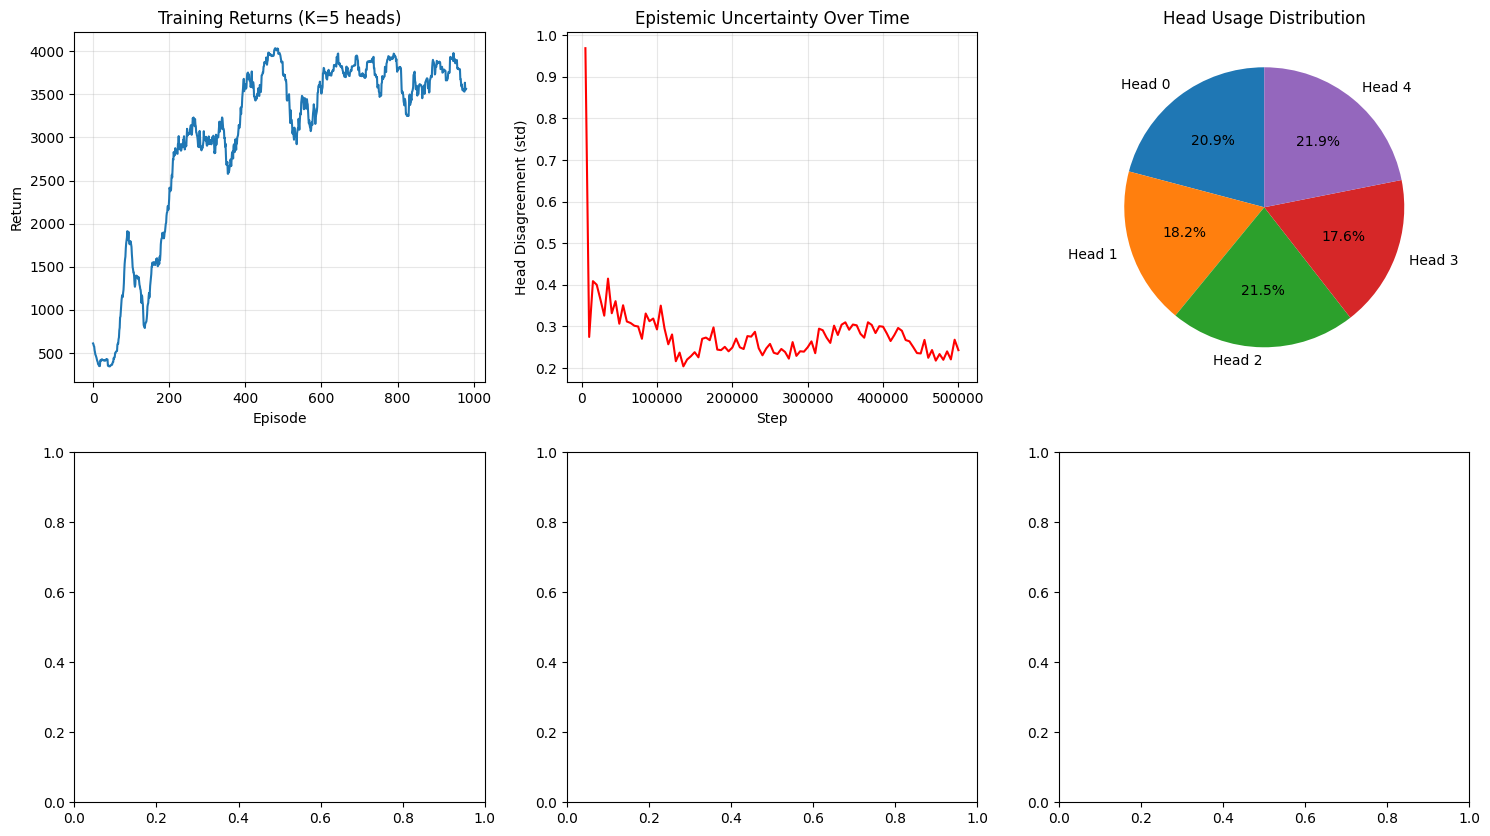

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Training metrics
if train_returns:
    window = min(20, len(train_returns))
    smoothed = np.convolve(train_returns, np.ones(window)/window, mode='valid')
    axes[0, 0].plot(smoothed)
    axes[0, 0].set_xlabel('Episode')
    axes[0, 0].set_ylabel('Return')
    axes[0, 0].set_title(f'Training Returns (K={cfg.num_heads} heads)')
    axes[0, 0].grid(True, alpha=0.3)

# Head disagreement over time
if disagreement_history:
    steps_d = [d[0] for d in disagreement_history]
    disagree_vals = [d[1] for d in disagreement_history]
    axes[0, 1].plot(steps_d, disagree_vals, 'r-')
    axes[0, 1].set_xlabel('Step')
    axes[0, 1].set_ylabel('Head Disagreement (std)')
    axes[0, 1].set_title('Epistemic Uncertainty Over Time')
    axes[0, 1].grid(True, alpha=0.3)

# Head usage pie chart
if cfg.num_heads > 1:
    axes[0, 2].pie(head_usage_counts, labels=[f'Head {i}' for i in range(cfg.num_heads)],
                   autopct='%1.1f%%', startangle=90)
    axes[0, 2].set_title('Head Usage Distribution')

# Row 2: Evaluation metrics
if eval_results:
    steps_e = [r[0] for r in eval_results]
    
    single_rewards = [r[1]['mean_reward'] for r in eval_results]
    ensemble_rewards = [r[2]['mean_reward'] for r in eval_results]
    thompson_rewards = [r[3]['mean_reward'] for r in eval_results]
    
    axes[1, 0].plot(steps_e, single_rewards, 'b-o', markersize=3, label='Single (head 0)')
    axes[1, 0].plot(steps_e, ensemble_rewards, 'g-s', markersize=3, label='Ensemble')
    axes[1, 0].plot(steps_e, thompson_rewards, 'r-^', markersize=3, label='Thompson')
    axes[1, 0].set_xlabel('Step')
    axes[1, 0].set_ylabel('Eval Reward')
    axes[1, 0].set_title('Evaluation Reward by Mode')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    single_sr = [r[1]['success_rate'] for r in eval_results]
    ensemble_sr = [r[2]['success_rate'] for r in eval_results]
    thompson_sr = [r[3]['success_rate'] for r in eval_results]
    
    axes[1, 1].plot(steps_e, single_sr, 'b-o', markersize=3, label='Single (head 0)')
    axes[1, 1].plot(steps_e, ensemble_sr, 'g-s', markersize=3, label='Ensemble')
    axes[1, 1].plot(steps_e, thompson_sr, 'r-^', markersize=3, label='Thompson')
    axes[1, 1].set_xlabel('Step')
    axes[1, 1].set_ylabel('Success Rate')
    axes[1, 1].set_title('Success Rate by Mode')
    axes[1, 1].set_ylim(-0.05, 1.05)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # Final comparison bar chart
    final_single = eval_results[-1][1]
    final_ensemble = eval_results[-1][2]
    final_thompson = eval_results[-1][3]
    
    modes = ['Single', 'Ensemble', 'Thompson']
    final_rewards = [final_single['mean_reward'], final_ensemble['mean_reward'], final_thompson['mean_reward']]
    final_success = [final_single['success_rate'], final_ensemble['success_rate'], final_thompson['success_rate']]
    
    x = np.arange(len(modes))
    width = 0.35
    ax2 = axes[1, 2].twinx()
    axes[1, 2].bar(x - width/2, final_rewards, width, label='Reward', color='steelblue')
    ax2.bar(x + width/2, [s*100 for s in final_success], width, label='Success %', color='forestgreen')
    axes[1, 2].set_ylabel('Reward', color='steelblue')
    ax2.set_ylabel('Success %', color='forestgreen')
    axes[1, 2].set_xticks(x)
    axes[1, 2].set_xticklabels(modes)
    axes[1, 2].set_title('Final Performance Comparison')
    axes[1, 2].legend(loc='upper left')
    ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig(f'bootflow_K{cfg.num_heads}_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Results saved to bootflow_K{cfg.num_heads}_results.png")

In [ ]:
# Final evaluation with more episodes
print(f"\nFinal Evaluation ({cfg.task_name}, K={cfg.num_heads} heads, 20 episodes each):")
print("=" * 60)

final_single = evaluate(agent, test_env, num_episodes=20, mode='single')
final_ensemble = evaluate(agent, test_env, num_episodes=20, mode='ensemble')
final_thompson = evaluate(agent, test_env, num_episodes=20, mode='thompson')

print(f"Single (head 0):")
print(f"  Mean Reward:  {final_single['mean_reward']:.2f} +/- {final_single['std_reward']:.2f}")
print(f"  Success Rate: {final_single['success_rate']:.2%}")

print(f"\nEnsemble (mean of K heads):")
print(f"  Mean Reward:  {final_ensemble['mean_reward']:.2f} +/- {final_ensemble['std_reward']:.2f}")
print(f"  Success Rate: {final_ensemble['success_rate']:.2%}")

print(f"\nThompson (random head per episode):")
print(f"  Mean Reward:  {final_thompson['mean_reward']:.2f} +/- {final_thompson['std_reward']:.2f}")
print(f"  Success Rate: {final_thompson['success_rate']:.2%}")

# Final disagreement
sample_states = replay_buffer.sample_states(1000)
final_disagree = agent.compute_head_disagreement(sample_states)
print(f"\nFinal Head Disagreement: {final_disagree['disagreement']:.4f}")
print(f"Max Disagreement: {final_disagree['max_disagreement']:.4f}")


Final Evaluation (reach-v3, K=5 heads, 20 episodes each):
Single (head 0):
  Mean Reward:  4020.81 +/- 9.36
  Success Rate: 0.00%

Ensemble (mean of K heads):
  Mean Reward:  4020.67 +/- 4.78
  Success Rate: 0.00%

Thompson (random head per episode):
  Mean Reward:  4021.38 +/- 11.13
  Success Rate: 0.00%

Final Head Disagreement: 0.0118
Max Disagreement: 0.1243
